In [3]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_unified_data, load_impact_links_from_excel
from src.impact_model import (
    build_association_matrix,
    plot_association_heatmap,
    create_event_dummies
)

# Load the main data (sheet 1) and the impact links (sheet 2)
df = load_unified_data()
impact_links = load_impact_links_from_excel()   # loads directly from Excel sheet 2

print("Main data shape:", df.shape)
print("Impact links shape:", impact_links.shape)
df.head(2)

Loaded 43 records from /home/meron-t-gebru/ethiopia-fi-forecast/data/raw/ethiopia_fi_unified_data.xlsx
Loaded 14 impact_link records from sheet 2
Main data shape: (43, 34)
Impact links shape: (14, 35)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN


In [4]:
# Check record types
print('Record types in main data:\n', df['record_type'].value_counts())

# Extract events
events = df[df['record_type'] == 'event'].copy()
print('\nNumber of events:', len(events))
events[['record_id', 'indicator', 'observation_date']].head()

Record types in main data:
 record_type
observation    30
event          10
target          3
Name: count, dtype: int64

Number of events: 10


,record_id,indicator,observation_date
33,EVT_0001,Telebirr Launch,2021-05-17
34,EVT_0002,Safaricom Ethiopia Commercial Launch,2022-08-01
35,EVT_0003,M-Pesa Ethiopia Launch,2023-08-01
36,EVT_0004,Fayda Digital ID Program Rollout,2024-01-01
37,EVT_0005,Foreign Exchange Liberalization,2024-07-29


Association matrix (numeric: 3=high, 2=medium, 1=low):
 related_indicator                                  ACC_4G_COV  ACC_MM_ACCOUNT  \
event_name                                                                      
EthioPay effect on P2P Count                              0.0             0.0   
FX Reform effect on Data Affordability                    0.0             0.0   
Fayda effect on Account Ownership                         0.0             0.0   
Fayda effect on Gender Gap                                0.0             0.0   
M-Pesa Interop effect on M-Pesa Active Users              0.0             0.0   
M-Pesa Interop effect on P2P Count                        0.0             0.0   
M-Pesa effect on M-Pesa Users                             0.0             0.0   
M-Pesa effect on Mobile Money Account Rate                0.0             2.0   
Safaricom Price Hike effect on Data Affordability         0.0             0.0   
Safaricom effect on 4G Coverage                      

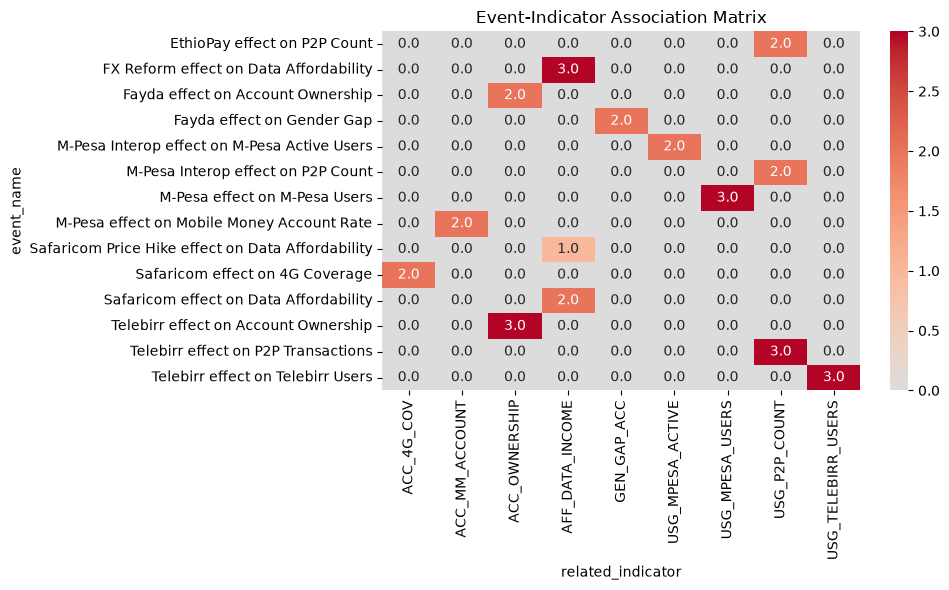

In [5]:
if not impact_links.empty:
    # Build the matrix using the updated numeric mapping function
    matrix = build_association_matrix(impact_links, events)
    print('Association matrix (numeric: 3=high, 2=medium, 1=low):\n', matrix)
    
    # Plot and save heatmap
    plot_association_heatmap(matrix)
else:
    print("No impact_link records found. Using a manually defined matrix instead.")
    # Fallback manual matrix (high/medium/low -> numeric)
    manual_impacts = [
        {'event': 'Telebirr Launch', 'ACC_MM_ACCOUNT': 3, 'USG_DIGITAL_PAYMENT': 2, 'ACC_OWNERSHIP': 1},
        {'event': 'M-Pesa Entry', 'ACC_MM_ACCOUNT': 3, 'USG_DIGITAL_PAYMENT': 2},
        {'event': 'Safaricom Market Entry', 'ACC_MOBILE_PEN': 2, 'ACC_MM_ACCOUNT': 1},
        {'event': 'Fayda Digital ID Integration', 'GEN_GAP_ACC': 2, 'ACC_OWNERSHIP': 2},
        {'event': 'FX Reform', 'AFF_DATA_INCOME': 3},
        {'event': 'Interoperable P2P', 'USG_CROSSOVER': 2, 'USG_DIGITAL_PAYMENT': 3},
        {'event': 'NFIS-II Target', 'ACC_OWNERSHIP': 3},
    ]
    matrix = pd.DataFrame(manual_impacts).set_index('event').fillna(0)
    print(matrix)
    plot_association_heatmap(matrix)

### Methodology Assumptions

- The association matrix is built from the `impact_link` records in the dataset (or manually estimated where data is missing).
- Impact magnitudes are qualitative categories (high/medium/low) converted to a numeric scale (3/2/1) for visualization.
- In the regression model (below), events are represented as dummy variables that turn on after the event date.
- The model assumes events have a **permanent** effect from their occurrence date onward.
- Due to sparse data (only 6 observations for many indicators), standard errors are large, and individual coefficients should not be interpreted as precise effect sizes.
- The model is intended as a **directional tool** for understanding which events matter most, not as a precise forecast.
- Backtesting against historical data helps validate the model's fit, but with small samples, overfitting is a risk.

In [6]:
# Prepare data for regression
events_df = df[df['record_type'] == 'event'].copy()
acc_ownership = create_event_dummies(df[df['record_type'] == 'observation'],
                                     events_df, 'ACC_OWNERSHIP', lag_months=0)
if not acc_ownership.empty:
    # Keep only event dummy columns and a time trend
    dummy_cols = [c for c in acc_ownership.columns if c.startswith('event_')]
    X = acc_ownership[dummy_cols].copy()
    X['year'] = acc_ownership.index.year
    y = acc_ownership['value_numeric'].copy()
    
    # Drop zero-variance columns (events that never turn on in the training period)
    X = X.loc[:, (X != 0).any(axis=0)]
    
    import statsmodels.api as sm
    X = sm.add_constant(X)
    model = sm.OLS(y, X, missing='drop').fit()
    print(model.summary())
else:
    print("No ACC_OWNERSHIP observations found.")

                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     1.784
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.379
Time:                        10:59:10   Log-Likelihood:                -19.033
No. Observations:                   6   AIC:                             46.07
Df Residuals:                       2   BIC:                             45.23
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -8705.3333   9501.161     -0.

/home/meron-t-gebru/ethiopia-fi-forecast/venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [7]:
if not acc_ownership.empty:
    # In-sample predictions
    train_pred = model.predict(sm.add_constant(X, has_constant='add'))
    backtest_df = pd.DataFrame({
        'Year': acc_ownership.index.year,
        'Actual': y.values,
        'Predicted': train_pred.values
    })
    print("Backtest comparison:")
    print(backtest_df)
    
    # Plot backtest
    plt.figure(figsize=(8,5))
    plt.plot(backtest_df['Year'], backtest_df['Actual'], 'o-', label='Actual')
    plt.plot(backtest_df['Year'], backtest_df['Predicted'], 's--', label='Model Predicted')
    plt.title('Model Backtest: Account Ownership (Historical Fit)')
    plt.ylabel('Share of adults (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig('../reports/figures/backtest_acc_ownership.png', dpi=150)
    plt.show()

ValueError: shapes (6,10) and (9,) not aligned: 10 (dim 1) != 9 (dim 0)